# Student Performance Analysis

This project analyzes student academic performance using the Student Performance dataset.
The goal is to clean the data, perform basic analysis, visualize results, and draw conclusions
using Python and its data science libraries.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Loading

The dataset was loaded using the Pandas library.
It contains information about students such as study time, gender, and final grades (G3).


In [9]:
print(df.shape)
df.info()

(395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  

In [10]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [11]:
df = df.drop_duplicates()

## Data Cleaning

The dataset was checked for missing values and duplicate records.
No major missing values were found, and duplicate rows were removed to ensure data quality.


In [12]:
df['G3'].mean()

np.float64(10.415189873417722)

In [13]:
df[df['G3'] > 15].shape[0]

40

In [14]:
df['studytime'].corr(df['G3'])

np.float64(0.09781968965319636)

In [15]:
df.groupby('sex')['G3'].mean()

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

## Data Analysis

Basic statistical analysis was performed to understand student performance.
This includes calculating the average final grade, identifying students with high scores,
analyzing the relationship between study time and grades, and comparing performance by gender.


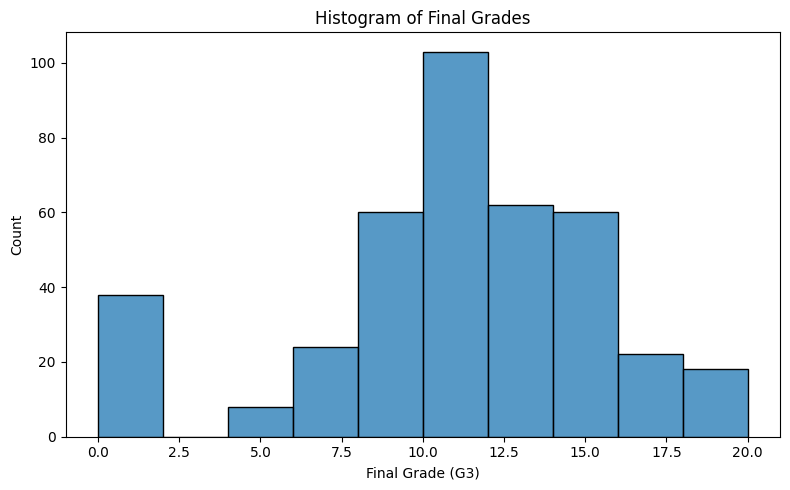

In [22]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=10, kde=False, color='C0')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Count')
plt.title('Histogram of Final Grades')
plt.tight_layout()
plt.savefig('histogram_G3.png')
plt.show()

**Interpretation (Histogram):**  
The histogram shows the distribution of students’ final grades (G3).
Most students score between **8 and 14**, indicating an average overall performance.
Very high scores (above 15) are less frequent, showing that top grades are achieved by fewer students.

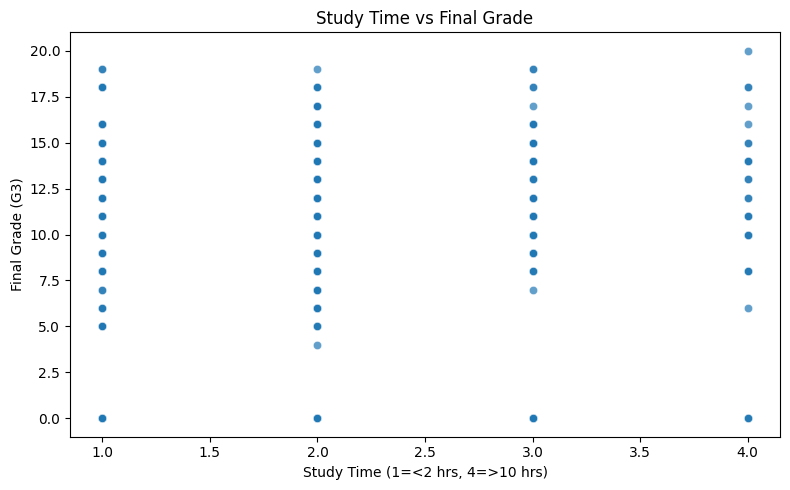

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='studytime', y='G3', data=df, alpha=0.7)
plt.xlabel('Study Time (1=<2 hrs, 4=>10 hrs)')
plt.ylabel('Final Grade (G3)')
plt.title('Study Time vs Final Grade')
plt.tight_layout()
plt.savefig('scatter_studytime_G3.png')
plt.show()

**Interpretation:**  
The scatter plot shows a weak positive relationship between study time and final grade.
Students who study more tend to score slightly higher, but the variation indicates that
study time alone does not strongly determine performance.

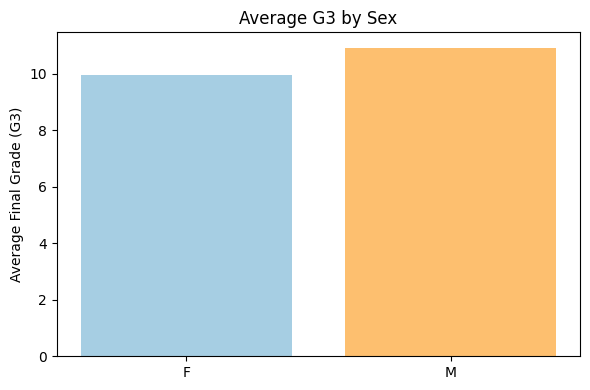

In [24]:
plt.figure(figsize=(6,4))
means = df.groupby('sex')['G3'].mean().reset_index()
colors = {'F':'#a6cee3', 'M':'#fdbf6f'}
plt.bar(means['sex'], means['G3'], color=[colors[s] for s in means['sex']])
plt.ylabel('Average Final Grade (G3)')
plt.title('Average G3 by Sex')
plt.tight_layout()
plt.savefig('bar_sex_G3.png')
plt.show()

**Interpretation (Bar Chart):**  
The bar chart compares the average final grades of male and female students.
Male students have a slightly higher average final grade than female students.
However, the difference is small, indicating that gender has a limited impact on overall academic performance.

## Conclusion
Study time shows a positive relationship with performance.